# 06. GLCM Texture Features
Extract Haralick texture features using the Grey-Level Co-occurrence Matrix (GLCM).

In [1]:
import curaster
import matplotlib.pyplot as plt
import os

input_file = "../build/benchmark_data/test_S_2048x2048.tif"

## Extract Contrast and Entropy
By default, `curaster` computes the average across 4 directions.

Texture array shape: (18, 2048, 2048), bands=18
Band mapping: 0=contrast, 1=entropy, 2=variance (subset of 18 Haralick features)


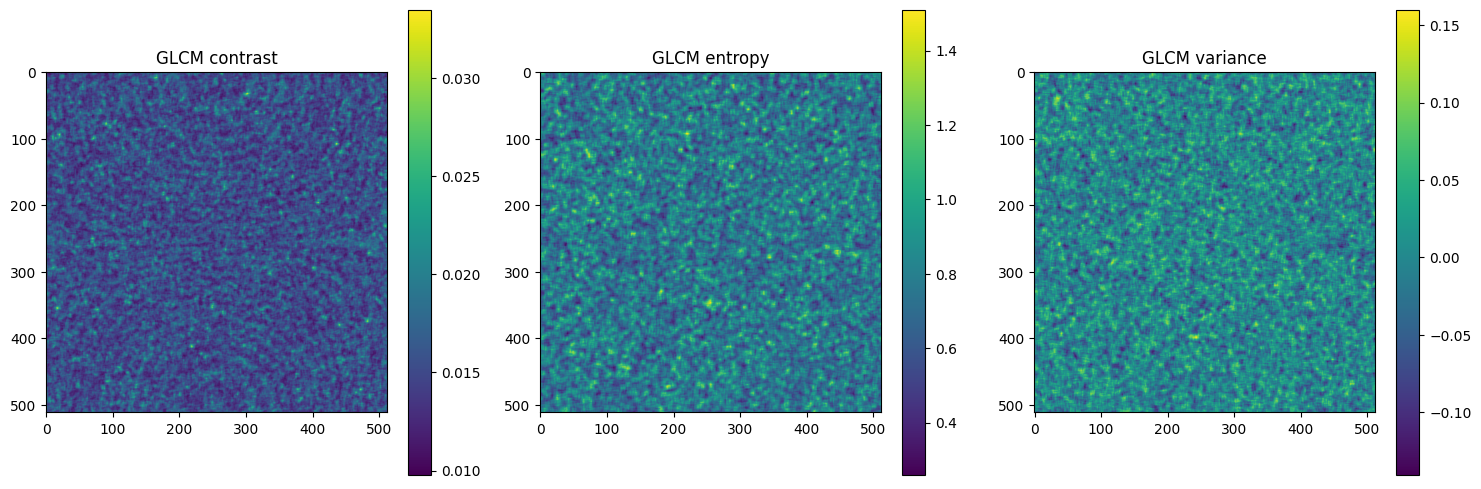

CPU times: user 45.2 s, sys: 1.42 s, total: 46.7 s
Wall time: 46.7 s


In [2]:
%%time
features = ["contrast", "entropy", "variance"]

result = curaster.open(input_file) \
    .algebra("B1") \
    .texture(features=features, window=7, levels=32, direction_mode="average") \
    .to_memory()

# to_memory() returns a 3D array [bands, height, width] for multi-band outputs
arr = result.data()
print(f"Texture array shape: {arr.shape}, bands={result.bands}")
print(f"Band mapping: 0=contrast, 1=entropy, 2=variance (subset of 18 Haralick features)")

# Plot all three feature bands side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, name in enumerate(features):
    # Show a central crop to avoid border artifacts
    axes[i].imshow(arr[i, 256:768, 256:768], cmap="viridis")
    axes[i].set_title(f"GLCM {name}")
    plt.colorbar(axes[i].images[0], ax=axes[i])
plt.tight_layout()
plt.show()

## Save Full 18-band Texture Output
All 18 Haralick features can be saved as a multi-band GeoTIFF directly.

In [3]:
%%time
curaster.open(input_file) \
    .algebra("B1") \
    .texture(window=7, levels=32) \
    .save_local("texture_output_18band.tif", verbose=True)
print("All 18 Haralick feature bands saved.")

0All 18 Haralick feature bands saved.
CPU times: user 51.5 s, sys: 1.69 s, total: 53.2 s
Wall time: 47.3 s
...10...20...30...40...50...60...70...80...90...100 - done.
